# Custom BKT — essential pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, mean_squared_error

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. Load & pre-process

In [2]:
df = pd.read_csv("25kfiles_kt1.csv")
df = df.drop(columns=["Unnamed: 0"])
df['question_id'] = df['question_id'].str.lstrip('q').astype(int)

In [3]:
df_question_content = pd.read_csv("contents\\questions.csv")

# Explode semi-colon-separated tags into one row per (question, skill)
df_question_content['tag_list'] = df_question_content['tags'].str.split(';')
df_question_content['question_id_int'] = (
    df_question_content['question_id'].str.lstrip('q').astype(int)
)

questions_exploded = df_question_content.explode('tag_list')
question_skills = (
    questions_exploded[['question_id_int', 'tag_list', 'correct_answer']]
    .drop_duplicates()
    .rename(columns={'question_id_int': 'question_id', 'tag_list': 'skill_name'})
)

In [4]:
df_merged = pd.merge(df, question_skills, on='question_id', how='left')
df_merged['correct'] = (df_merged['user_answer'] == df_merged['correct_answer']).astype(int)

# Chronological attempt index per student (global, used as order_id)
df_merged = df_merged.sort_values(['user_id', 'timestamp'])
df_merged['order_id'] = df_merged.groupby('user_id').cumcount() + 1

df_bkt = df_merged[['user_id', 'skill_name', 'correct', 'order_id']]
df_bkt.head()

,user_id,skill_name,correct,order_id
0,1,74,0,1
1,1,71,1,2
2,1,103,1,3
3,1,83,0,4
4,1,90,0,5


## 2. Custom BKT (Baum-Welch EM)

Two-state HMM:
- State 0 = not learned, State 1 = learned (no forgetting)
- Transition: `A[0→1] = learn`, `A[1→1] = 1`
- Emission: `P(correct | 0) = guess`, `P(correct | 1) = 1 − slip`

In [5]:
def forward_pass(sequence, prior, learn, guess, slip):
    """Filtered P(correct) at each step — used for predictions only."""
    p_l = prior
    predictions = []
    for correct in sequence:
        p_correct = p_l * (1 - slip) + (1 - p_l) * guess
        predictions.append(p_correct)
        if correct == 1:
            num = p_l * (1 - slip)
            den = num + (1 - p_l) * guess
        else:
            num = p_l * slip
            den = num + (1 - p_l) * (1 - guess)
        p_l_given_obs = num / den if den > 0 else p_l
        p_l = p_l_given_obs + (1 - p_l_given_obs) * learn
    return predictions


def fit_skill(sequences, n_iter=100, tol=1e-5,
              init_prior=0.3, init_learn=0.1,
              init_guess=0.2, init_slip=0.1):
    """Fit one skill via Baum-Welch EM (scaled forward-backward)."""
    seqs = [np.asarray(s, dtype=np.int8) for s in sequences if len(s) > 0]
    if not seqs:
        return {'prior': init_prior, 'learn': init_learn,
                'guess': init_guess, 'slip': init_slip,
                'n_sequences': 0, 'n_obs': 0,
                'log_likelihood': float('nan'), 'iterations': 0}

    prior, learn, guess, slip = init_prior, init_learn, init_guess, init_slip
    prev_ll = -np.inf

    for it in range(n_iter):
        sum_prior_post = 0.0
        n_seq = 0
        sum_xi_01 = 0.0
        sum_gamma0_trans = 0.0
        sum_correct_nl = 0.0
        sum_total_nl = 0.0
        sum_wrong_l = 0.0
        sum_total_l = 0.0
        total_ll = 0.0
        n_obs_total = 0

        A00, A01 = 1 - learn, learn

        for seq in seqs:
            T = len(seq)
            n_obs_total += T

            b = np.empty((T, 2))
            b[:, 0] = np.where(seq == 1, guess,    1 - guess)
            b[:, 1] = np.where(seq == 1, 1 - slip, slip)

            # Forward with scaling
            alpha = np.empty((T, 2))
            scale = np.empty(T)
            alpha[0, 0] = (1 - prior) * b[0, 0]
            alpha[0, 1] =      prior  * b[0, 1]
            scale[0] = alpha[0].sum()
            if scale[0] > 0: alpha[0] /= scale[0]
            for t in range(1, T):
                alpha[t, 0] = b[t, 0] * alpha[t-1, 0] * A00
                alpha[t, 1] = b[t, 1] * (alpha[t-1, 0] * A01 + alpha[t-1, 1])
                scale[t] = alpha[t].sum()
                if scale[t] > 0: alpha[t] /= scale[t]
            total_ll += np.sum(np.log(scale + 1e-300))

            # Backward with same scaling
            beta = np.empty((T, 2))
            beta[T-1] = 1.0 / (scale[T-1] if scale[T-1] > 0 else 1.0)
            for t in range(T-2, -1, -1):
                beta[t, 0] = A00 * b[t+1, 0] * beta[t+1, 0] + A01 * b[t+1, 1] * beta[t+1, 1]
                beta[t, 1] =       b[t+1, 1] * beta[t+1, 1]
                if scale[t] > 0: beta[t] /= scale[t]

            # State posteriors γ
            gamma = alpha * beta
            gs = gamma.sum(axis=1, keepdims=True)
            gamma = np.where(gs > 0, gamma / gs, gamma)

            # Transition posteriors ξ (no-forget → ξ[1→0] = 0)
            if T > 1:
                xi00 = alpha[:-1, 0] * A00 * b[1:, 0] * beta[1:, 0]
                xi01 = alpha[:-1, 0] * A01 * b[1:, 1] * beta[1:, 1]
                xi11 = alpha[:-1, 1] *        b[1:, 1] * beta[1:, 1]
                z = xi00 + xi01 + xi11
                ok = z > 0
                xi01n = np.where(ok, xi01 / np.where(ok, z, 1.0), 0.0)
                xi00n = np.where(ok, xi00 / np.where(ok, z, 1.0), 0.0)
                sum_xi_01       += xi01n.sum()
                sum_gamma0_trans += (xi00n + xi01n).sum()

            sum_prior_post  += gamma[0, 1]
            n_seq           += 1
            sum_total_nl    += gamma[:, 0].sum()
            sum_total_l     += gamma[:, 1].sum()
            sum_correct_nl  += gamma[seq == 1, 0].sum()
            sum_wrong_l     += gamma[seq == 0, 1].sum()

        # M-step
        prior = float(np.clip(sum_prior_post / max(n_seq, 1), 0.01, 0.99))
        learn = float(np.clip(sum_xi_01 / max(sum_gamma0_trans, 1e-12), 0.001, 0.99))
        guess = float(np.clip(sum_correct_nl / max(sum_total_nl, 1e-12), 0.001, 0.4))
        slip  = float(np.clip(sum_wrong_l  / max(sum_total_l,  1e-12), 0.001, 0.4))

        if abs(total_ll - prev_ll) < tol:
            break
        prev_ll = total_ll

    return {'prior': prior, 'learn': learn, 'guess': guess, 'slip': slip,
            'n_sequences': len(seqs), 'n_obs': n_obs_total,
            'log_likelihood': total_ll, 'iterations': it + 1}


def fit_bkt(df, n_iter=100, min_attempts_per_student=2, verbose=True):
    """Fit BKT for all skills (drops length-1 sequences)."""
    params = {}
    skills = df['skill_name'].unique()
    for idx, skill in enumerate(skills):
        skill_df = df[df['skill_name'] == skill].sort_values(['user_id', 'order_id'])
        sequences = [
            group['correct'].tolist()
            for _, group in skill_df.groupby('user_id')
            if len(group) >= min_attempts_per_student
        ]
        if sequences:
            params[skill] = fit_skill(sequences, n_iter=n_iter)
        if verbose and (idx + 1) % 25 == 0:
            print(f"  fitted {idx+1}/{len(skills)} skills")
    return params


def predict_bkt(df, params):
    """Generate per-attempt P(correct) predictions from fitted params."""
    df = df.copy().sort_values(['user_id', 'skill_name', 'order_id'])
    df['correct_predictions'] = np.nan
    for (user, skill), group in df.groupby(['user_id', 'skill_name']):
        if skill not in params:
            continue
        p = params[skill]
        preds = forward_pass(group['correct'].tolist(),
                             prior=p['prior'], learn=p['learn'],
                             guess=p['guess'], slip=p['slip'])
        df.loc[group.index, 'correct_predictions'] = preds
    return df

## 3. Fit & predict

In [6]:
print("Fitting BKT for", df_bkt['skill_name'].nunique(), "skills...")
bkt_params = fit_bkt(df_bkt, n_iter=100, min_attempts_per_student=2)
print(f"Done — {len(bkt_params)} skills fitted.")

params_df = pd.DataFrame(bkt_params).T.round(4)
params_df.index.name = 'skill'
params_df.head(10)

Fitting BKT for 189 skills...
  fitted 25/189 skills
  fitted 50/189 skills
  fitted 75/189 skills


KeyboardInterrupt: 

In [7]:
df_predictions = predict_bkt(df_bkt, bkt_params)
df_predictions[['user_id', 'skill_name', 'correct', 'correct_predictions']].head(10)

,user_id,skill_name,correct,correct_predictions
1085,1,1,1,0.812022
1260,1,1,1,0.829934
1364,1,10,1,0.819776
1999,1,10,0,0.835533
2027,1,10,0,0.817231
2030,1,10,1,0.772824
2033,1,10,1,0.815838
2036,1,10,1,0.833969
461,1,100,1,0.288219
387,1,101,0,0.570325


## 4. Evaluation metrics

In [8]:
valid = df_predictions.dropna(subset=['correct_predictions'])

auc  = roc_auc_score(valid['correct'], valid['correct_predictions']) if valid['correct'].nunique() == 2 else float('nan')
rmse = mean_squared_error(valid['correct'], valid['correct_predictions']) ** 0.5

print(f"Overall AUC:   {auc:.4f}")
print(f"Overall RMSE:  {rmse:.4f}")
print(f"N predictions: {len(valid):,}")

print("\nParameter distribution across skills:")
print(params_df[['prior', 'learn', 'guess', 'slip']].describe().round(3))

print("\nIdentifiability check (guess + slip should be < 1):")
print((params_df['guess'] + params_df['slip']).describe().round(3))

Overall AUC:   0.6343
Overall RMSE:  0.4436
N predictions: 3,361,609

Parameter distribution across skills:
         prior    learn    guess     slip
count  189.000  189.000  189.000  189.000
mean     0.690    0.124    0.382    0.245
std      0.258    0.194    0.058    0.070
min      0.010    0.001    0.001    0.001
25%      0.630    0.019    0.400    0.206
50%      0.772    0.036    0.400    0.239
75%      0.864    0.131    0.400    0.290
max      0.990    0.990    0.400    0.400

Identifiability check (guess + slip should be < 1):
count    189.000
mean       0.628
std        0.096
min        0.002
25%        0.593
50%        0.631
75%        0.679
max        0.800
dtype: float64


In [9]:
# Per-skill AUC & RMSE
skill_metrics = (
    valid.groupby('skill_name')
    .apply(lambda g: pd.Series({
        'auc':  roc_auc_score(g['correct'], g['correct_predictions'])
                if g['correct'].nunique() == 2 else np.nan,
        'rmse': mean_squared_error(g['correct'], g['correct_predictions']) ** 0.5,
        'n':    len(g),
    }))
    .reset_index()
)
skill_metrics.sort_values('auc', ascending=False).head(10)

,skill_name,auc,rmse,n
102,219,0.794118,0.394285,26.0
144,59,0.760983,0.438944,30403.0
50,145,0.754124,0.433933,7040.0
162,75,0.715084,0.450799,8929.0
85,177,0.714756,0.456608,32743.0
145,6,0.710237,0.441108,14685.0
76,169,0.708557,0.476749,5714.0
137,52,0.708172,0.451170,83427.0
156,7,0.693846,0.445886,37279.0
3,100,0.690833,0.462505,7789.0


## 5. Visualisations

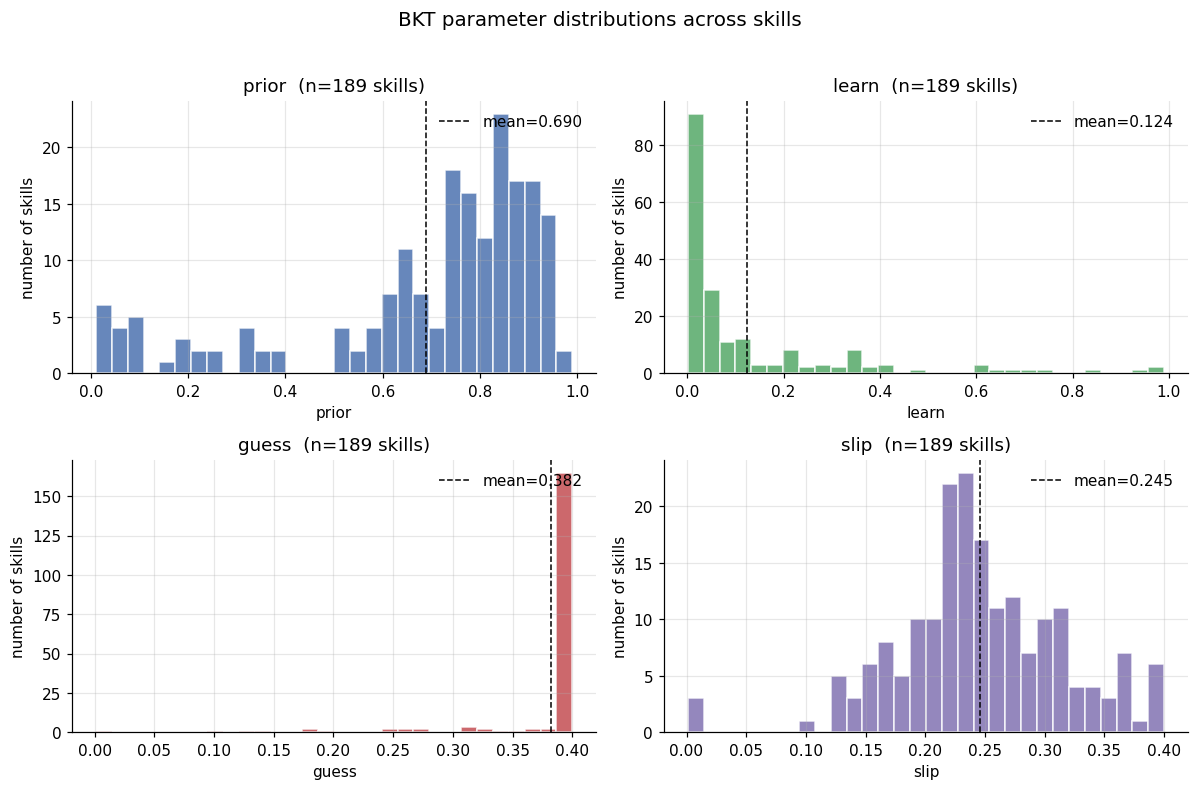

In [10]:
# ── 1. Parameter distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, color in zip(
    axes.flat,
    ['prior', 'learn', 'guess', 'slip'],
    ['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
):
    ax.hist(params_df[col], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(params_df[col].mean(), color='black', linestyle='--', linewidth=1,
               label=f"mean={params_df[col].mean():.3f}")
    ax.set_title(f"{col}  (n={len(params_df)} skills)")
    ax.set_xlabel(col); ax.set_ylabel('number of skills')
    ax.legend(loc='upper right', frameon=False)
fig.suptitle("BKT parameter distributions across skills", y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

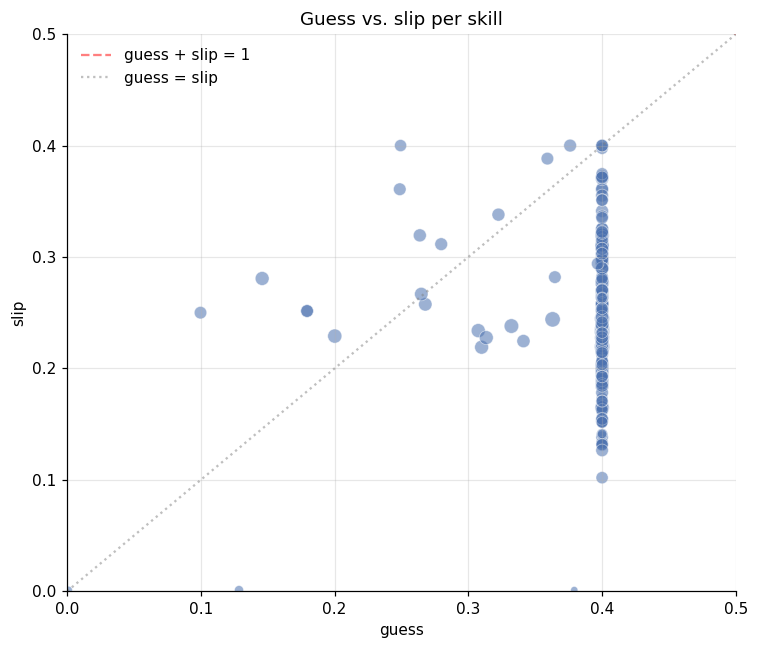

In [11]:
# ── 2. Guess vs. slip (identifiability) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sizes = np.log1p(params_df['n_obs']) * 8 if 'n_obs' in params_df.columns else 40
ax.scatter(params_df['guess'], params_df['slip'],
           s=sizes, alpha=0.55, c='#4C72B0', edgecolor='white', linewidth=0.5)
xs = np.linspace(0, 0.5, 50)
ax.plot(xs, 1 - xs, '--', color='red',  alpha=0.5, label='guess + slip = 1')
ax.plot([0, 0.5], [0, 0.5], ':',  color='gray', alpha=0.5, label='guess = slip')
ax.set_xlabel('guess'); ax.set_ylabel('slip')
ax.set_xlim(0, 0.5);   ax.set_ylim(0, 0.5)
ax.set_title("Guess vs. slip per skill")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

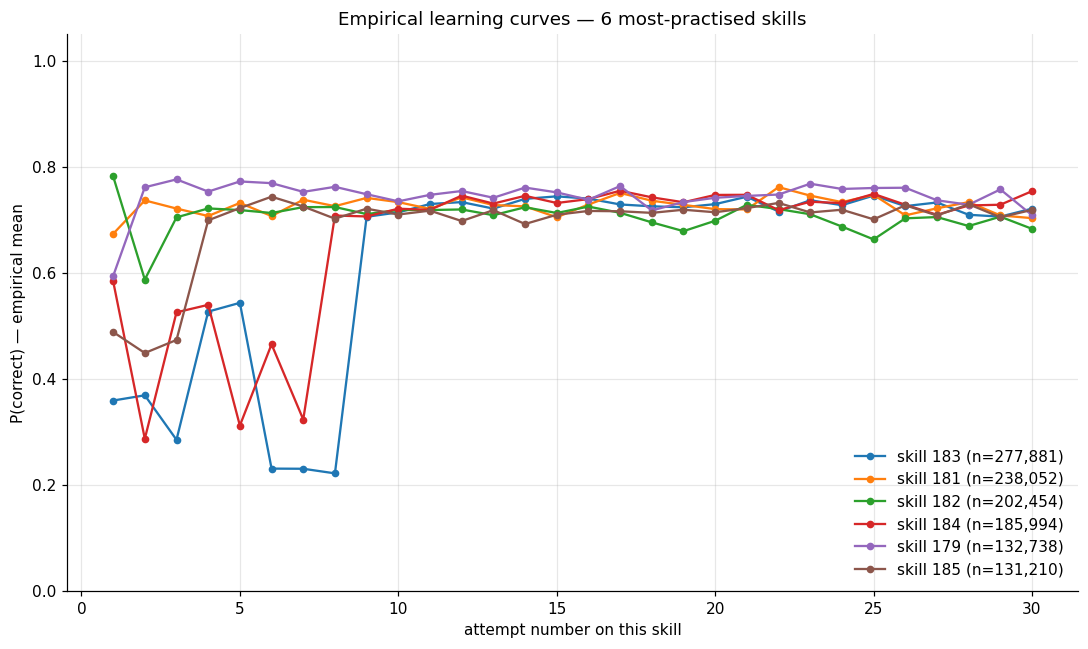

In [12]:
# ── 3. Empirical learning curves (top 6 skills) ────────────────────────────
top_skills = df_bkt['skill_name'].value_counts().head(6).index.tolist()
fig, ax = plt.subplots(figsize=(10, 6))
for skill in top_skills:
    sub = df_bkt[df_bkt['skill_name'] == skill].copy()
    sub['skill_attempt'] = sub.groupby('user_id').cumcount() + 1
    curve = sub.groupby('skill_attempt')['correct'].agg(['mean', 'count'])
    curve = curve[curve['count'] >= 20]
    ax.plot(curve.index[:30], curve['mean'].values[:30],
            marker='o', markersize=4, label=f"skill {skill} (n={len(sub):,})")
ax.set_xlabel('attempt number on this skill')
ax.set_ylabel('P(correct) — empirical mean')
ax.set_title("Empirical learning curves — 6 most-practised skills")
ax.legend(frameon=False, loc='lower right'); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

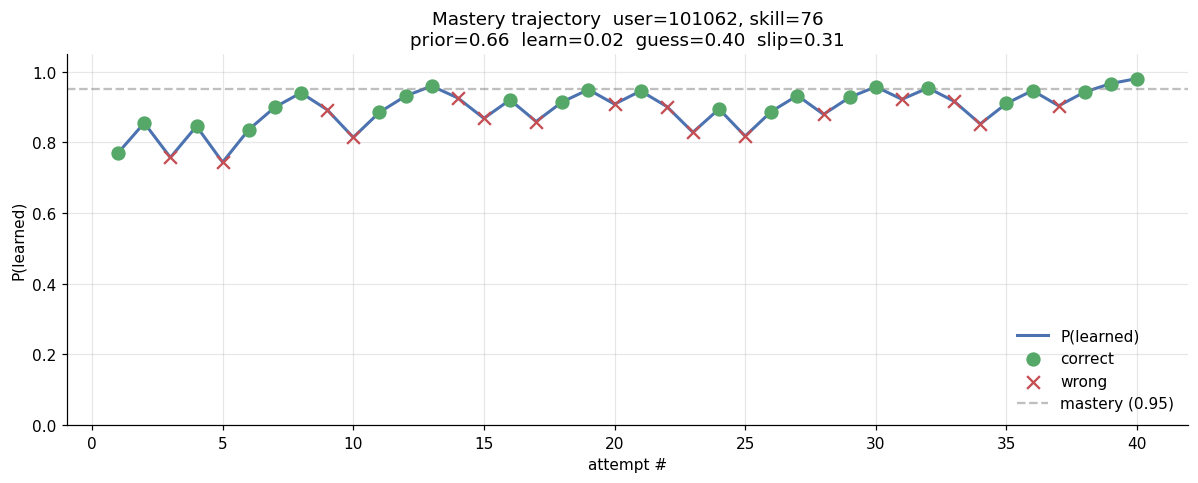

In [13]:
# ── 4. Mastery trajectory for one student–skill pair ───────────────────────
candidates = (df_bkt.groupby(['user_id', 'skill_name']).size()
              .reset_index(name='n').query('15 <= n <= 40')
              .sort_values('n', ascending=False))

if len(candidates) > 0:
    pick = candidates.iloc[11]
    u, sk = int(pick['user_id']), pick['skill_name']
    sub = (df_bkt[(df_bkt['user_id'] == u) & (df_bkt['skill_name'] == sk)]
           .sort_values('order_id'))
    obs = sub['correct'].tolist()
    p   = bkt_params[sk]

    p_l_trace, p_l = [], p['prior']
    for c in obs:
        num = p_l * (1 - p['slip']) if c == 1 else p_l * p['slip']
        den = (num + (1 - p_l) * p['guess']) if c == 1 else (num + (1 - p_l) * (1 - p['guess']))
        p_l = (num / den if den > 0 else p_l)
        p_l = p_l + (1 - p_l) * p['learn']
        p_l_trace.append(p_l)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    xs  = np.arange(1, len(obs) + 1)
    obs_arr = np.array(obs)
    ax.plot(xs, p_l_trace, '-', color='#4C72B0', linewidth=2, label='P(learned)')
    ax.scatter(xs[obs_arr == 1], np.array(p_l_trace)[obs_arr == 1],
               marker='o', s=70, color='#55A868', label='correct', zorder=5)
    ax.scatter(xs[obs_arr == 0], np.array(p_l_trace)[obs_arr == 0],
               marker='x', s=70, color='#C44E52', label='wrong',   zorder=5)
    ax.axhline(0.95, linestyle='--', color='gray', alpha=0.5, label='mastery (0.95)')
    ax.set_xlabel('attempt #'); ax.set_ylabel('P(learned)')
    ax.set_title(f"Mastery trajectory  user={u}, skill={sk}\n"
                 f"prior={p['prior']:.2f}  learn={p['learn']:.2f}  "
                 f"guess={p['guess']:.2f}  slip={p['slip']:.2f}")
    ax.set_ylim(0, 1.05); ax.legend(frameon=False, loc='lower right')
    plt.tight_layout(); plt.show()
else:
    print("No candidate pair with 15–40 attempts found.")

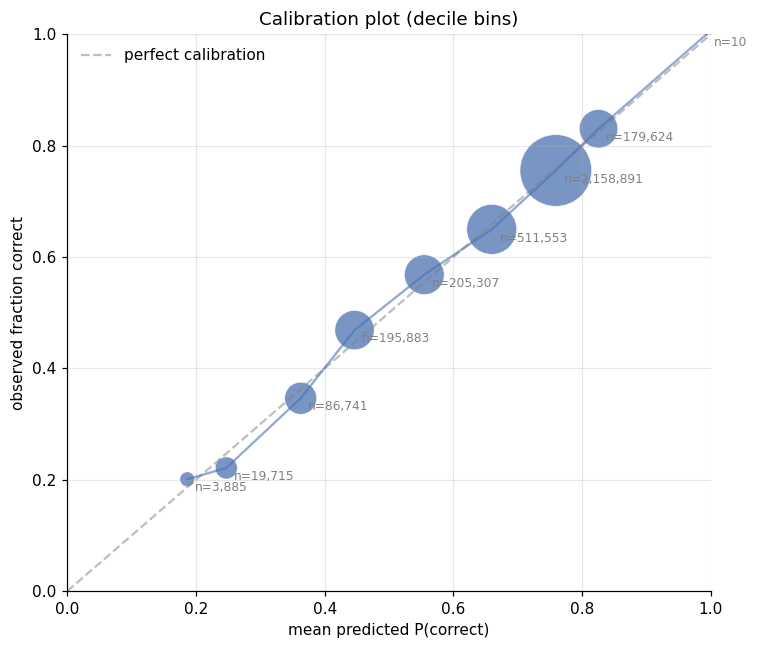

In [14]:
# ── 5. Calibration plot ─────────────────────────────────────────────────────
bins = np.linspace(0, 1, 11)
valid2 = valid.copy()
valid2['pred_bin'] = pd.cut(valid2['correct_predictions'], bins, include_lowest=True)
cal = valid2.groupby('pred_bin', observed=True).agg(
    pred_mean=('correct_predictions', 'mean'),
    obs_mean =('correct',             'mean'),
    n        =('correct',             'size'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='perfect calibration')
ax.scatter(cal['pred_mean'], cal['obs_mean'],
           s=np.sqrt(cal['n']) * 1.5, alpha=0.75,
           color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.plot(cal['pred_mean'], cal['obs_mean'], '-', color='#4C72B0', alpha=0.6)
for _, row in cal.iterrows():
    ax.annotate(f"n={int(row['n']):,}", (row['pred_mean'], row['obs_mean']),
                xytext=(5, -8), textcoords='offset points', fontsize=8, color='gray')
ax.set_xlabel('mean predicted P(correct)')
ax.set_ylabel('observed fraction correct')
ax.set_title("Calibration plot (decile bins)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

In [18]:
skill_metrics = (valid.groupby('skill_name')
    .apply(lambda g: pd.Series({
        'auc': roc_auc_score(g['correct'], g['correct_predictions']) if g['correct'].nunique() == 2 else np.nan,
        'rmse': mean_squared_error(g['correct'], g['correct_predictions']) ** 0.5,
        'n': len(g)
    })).reset_index())
skill_metrics

,skill_name,auc,rmse,n
0,-1,0.562449,0.417173,242.0
1,1,0.571767,0.379237,4416.0
2,10,0.532324,0.370183,4105.0
3,100,0.690833,0.462505,7789.0
4,101,0.534646,0.478927,4436.0
...,...,...,...,...
184,95,0.556535,0.480931,7912.0
185,96,0.566625,0.479797,11392.0
186,97,0.553896,0.496649,4350.0
187,98,0.566745,0.437599,11425.0


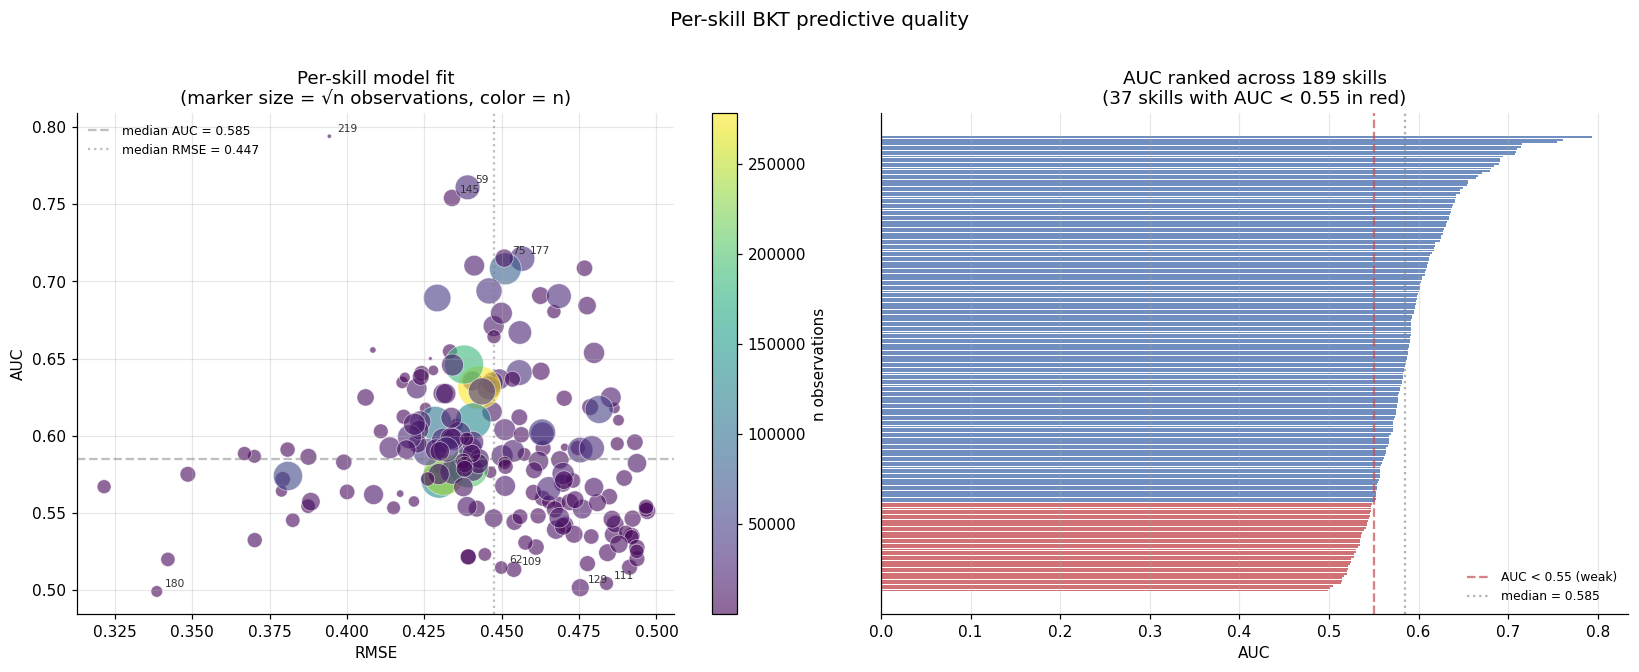

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- 1. AUC vs RMSE scatter, sized by n ----
ax = axes[0]
sizes = np.sqrt(skill_metrics['n']) * 1.5
sc = ax.scatter(
    skill_metrics['rmse'], skill_metrics['auc'],
    s=sizes, alpha=0.6,
    c=skill_metrics['n'], cmap='viridis',
    edgecolor='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='n observations')

# Reference lines: median AUC and RMSE
ax.axhline(skill_metrics['auc'].median(), color='gray', linestyle='--', alpha=0.5,
           label=f"median AUC = {skill_metrics['auc'].median():.3f}")
ax.axvline(skill_metrics['rmse'].median(), color='gray', linestyle=':', alpha=0.5,
           label=f"median RMSE = {skill_metrics['rmse'].median():.3f}")

# Label outliers: top/bottom 5 by AUC
for _, row in pd.concat([
    skill_metrics.nlargest(5, 'auc'),
    skill_metrics.nsmallest(5, 'auc')
]).iterrows():
    ax.annotate(str(row['skill_name']), (row['rmse'], row['auc']),
                xytext=(5, 3), textcoords='offset points', fontsize=7, color='#333')

ax.set_xlabel('RMSE'); ax.set_ylabel('AUC')
ax.set_title('Per-skill model fit\n(marker size = √n observations, color = n)')
ax.legend(frameon=False, fontsize=8)

# ---- 2. AUC distribution with flagging ----
ax2 = axes[1]
colors = ['#C44E52' if v < 0.55 else '#4C72B0' for v in skill_metrics['auc']]
skill_metrics_sorted = skill_metrics.sort_values('auc')
ax2.barh(range(len(skill_metrics_sorted)), skill_metrics_sorted['auc'],
         color=[('#C44E52' if v < 0.55 else '#4C72B0') for v in skill_metrics_sorted['auc']],
         alpha=0.8)
ax2.axvline(0.55, color='#C44E52', linestyle='--', alpha=0.7, label='AUC < 0.55 (weak)')
ax2.axvline(skill_metrics['auc'].median(), color='gray', linestyle=':', alpha=0.6,
            label=f"median = {skill_metrics['auc'].median():.3f}")
ax2.set_yticks([])
ax2.set_xlabel('AUC')
ax2.set_title(f'AUC ranked across {len(skill_metrics)} skills\n'
              f'({(skill_metrics["auc"] < 0.55).sum()} skills with AUC < 0.55 in red)')
ax2.legend(frameon=False, fontsize=8)

fig.suptitle('Per-skill BKT predictive quality', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()